#Importing Modules


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings("ignore")
%matplotlib inline
from keras.preprocessing.image import load_img
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D

#Loading Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


In [3]:
TRAIN_DIR = '/kaggle/input/fer2013/train'
TEST_DIR = '/kaggle/input/fer2013/test'

In [4]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))


GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
def load_dataset(directory):
  image_paths=[]
  labels=[]
  for label in os.listdir(directory):
    for filename in os.listdir(directory + label):
      image_path=os.path.join(directory,label,filename)
      image_paths.append(image_path)
      labels.append(label)
    print(label,"Completed")
  return image_paths,labels

In [6]:
import os
import pandas as pd

def load_dataset(directory):
    image_paths = []
    labels = []
    for label in os.listdir(directory):
        label_path = os.path.join(directory, label)   # Correct path
        for filename in os.listdir(label_path):
            image_path = os.path.join(label_path, filename)
            image_paths.append(image_path)
            labels.append(label)
        print(label, "Completed")
    return image_paths, labels

# Load dataset into dataframe
train = pd.DataFrame()
train['image'], train['label'] = load_dataset(TRAIN_DIR)

# Shuffle rows
train = train.sample(frac=1).reset_index(drop=True)

# Show first few rows
print(train.head())


surprise Completed
fear Completed
angry Completed
neutral Completed
sad Completed
disgust Completed
happy Completed
                                               image    label
0  /kaggle/input/fer2013/train/neutral/Training_2...  neutral
1  /kaggle/input/fer2013/train/happy/Training_442...    happy
2  /kaggle/input/fer2013/train/fear/Training_4031...     fear
3  /kaggle/input/fer2013/train/happy/Training_369...    happy
4  /kaggle/input/fer2013/train/fear/Training_5520...     fear


In [7]:
test = pd.DataFrame()
test['image'], test['label'] = load_dataset(TEST_DIR)

# Shuffle rows
test = test.sample(frac=1).reset_index(drop=True)

# Show first few rows
print(test.head())

surprise Completed
fear Completed
angry Completed
neutral Completed
sad Completed
disgust Completed
happy Completed
                                               image    label
0  /kaggle/input/fer2013/test/disgust/PrivateTest...  disgust
1  /kaggle/input/fer2013/test/sad/PublicTest_4197...      sad
2  /kaggle/input/fer2013/test/neutral/PublicTest_...  neutral
3  /kaggle/input/fer2013/test/sad/PublicTest_9146...      sad
4  /kaggle/input/fer2013/test/sad/PublicTest_5336...      sad


#Exploratory Data Analysis

<Axes: xlabel='count', ylabel='label'>

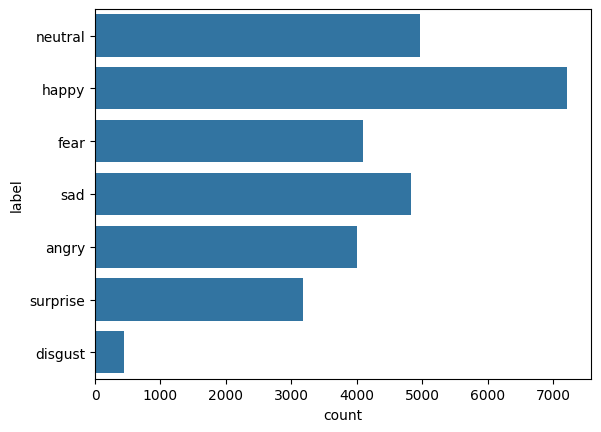

In [8]:
sns.countplot(train['label'])

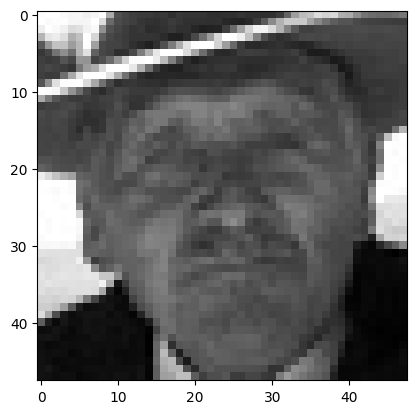

In [9]:
from PIL import Image
img=Image.open(train['image'][0])
plt.imshow(img,cmap='gray');

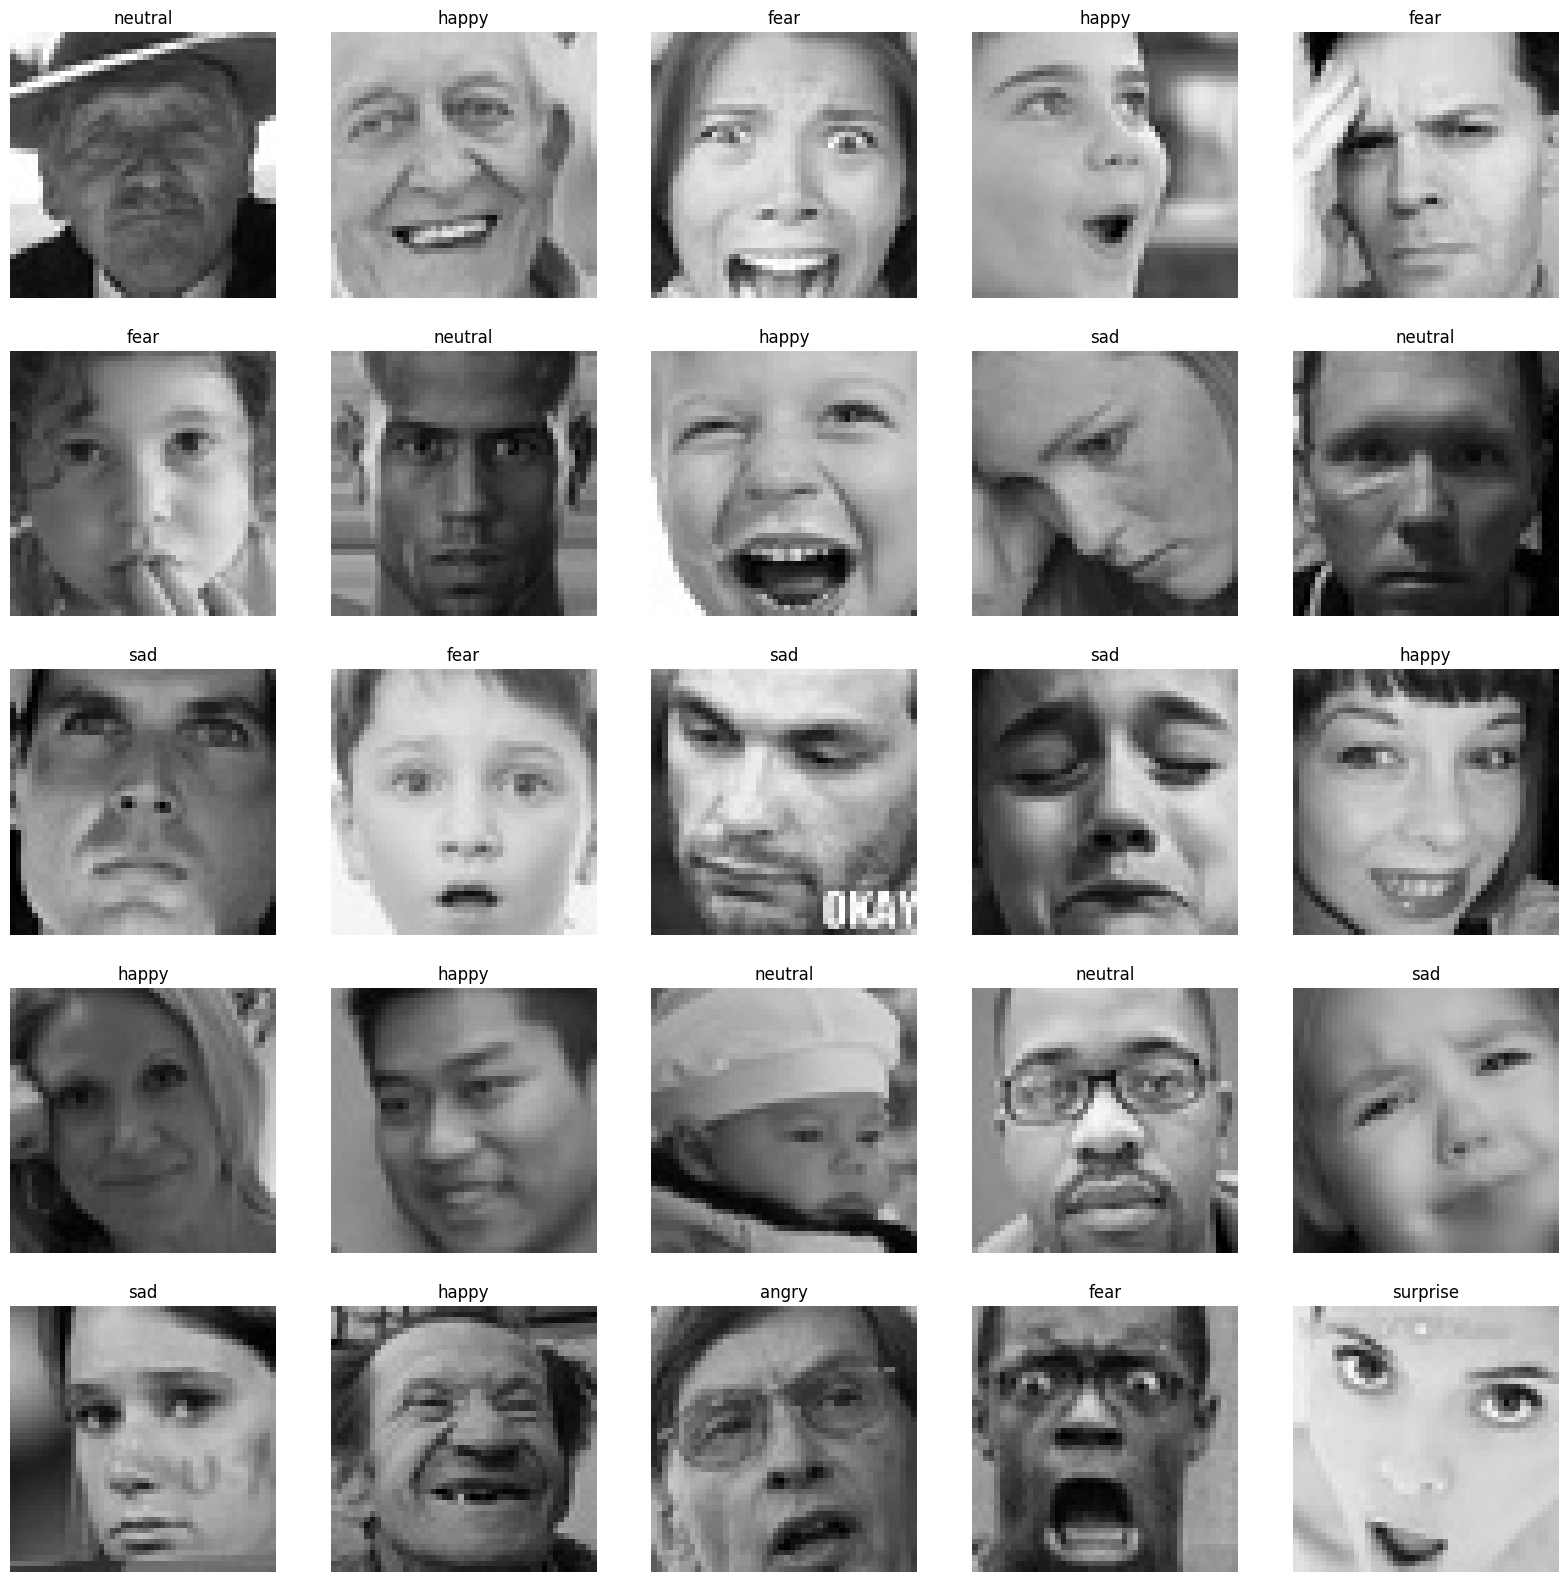

In [10]:
plt.figure(figsize=(20,20))
files=train.iloc[0:25]
for index, file, label in files.itertuples():
  plt.subplot(5,5,index+1)
  img=load_img(file)
  img=np.array(img)
  plt.imshow(img)
  plt.title(label)
  plt.axis('off')

#Feature Extraction

In [11]:
import numpy as np
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def extract_features(images):
    features = []
    for image in tqdm(images):
        # Load image in grayscale
        img = load_img(image, color_mode="grayscale", target_size=(48,48,1))
        img_array = img_to_array(img)
        features.append(img_array)

    features = np.array(features)
    features = features.reshape(len(features), 48, 48, 1)  # shape: (N, 48, 48, 1)
    return features


In [12]:
train_featurse=extract_features(train['image'])


100%|██████████| 28709/28709 [02:39<00:00, 179.69it/s]


In [13]:
test_featurse=extract_features(test['image'])

100%|██████████| 7178/7178 [00:34<00:00, 206.29it/s]


In [14]:
x_train=train_featurse/255.0
x_test=test_featurse/255.0


In [15]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le.fit(train['label'])
y_train=le.transform(train['label'])
y_test=le.transform(test['label'])

In [16]:
y_train=to_categorical(y_train, num_classes=7)
y_test=to_categorical(y_test, num_classes=7)

In [17]:
y_train[0]

array([0., 0., 0., 0., 1., 0., 0.])

In [18]:
input_shape=(48,48,1)
output_class=7


#Model Creation

In [19]:
model=Sequential()
model.add(Conv2D(128,kernel_size=(3,3),activation='relu',input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(256,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512,kernel_size=(3,3),activation='relu',))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Flatten())

model.add(Dense(512,activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(output_class,activation='softmax'))

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [20]:
history=model.fit(x=x_train, y=y_train,batch_size=128, epochs= 100,validation_data=(x_test,y_test))

Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step - accuracy: 0.2397 - loss: 1.8389 - val_accuracy: 0.2471 - val_loss: 1.8153
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.2519 - loss: 1.8139 - val_accuracy: 0.2499 - val_loss: 1.7979
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.2559 - loss: 1.7808 - val_accuracy: 0.3233 - val_loss: 1.6755
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.3261 - loss: 1.6559 - val_accuracy: 0.4174 - val_loss: 1.4892
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.4039 - loss: 1.5276 - val_accuracy: 0.4646 - val_loss: 1.3710
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.4435 - loss: 1.4465 - val_accuracy: 0.4890 - val_loss: 1.3406
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.4547 - loss: 1.4093 - val_accuracy: 0.4939 - val_loss: 1.3096
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.4736 - loss: 

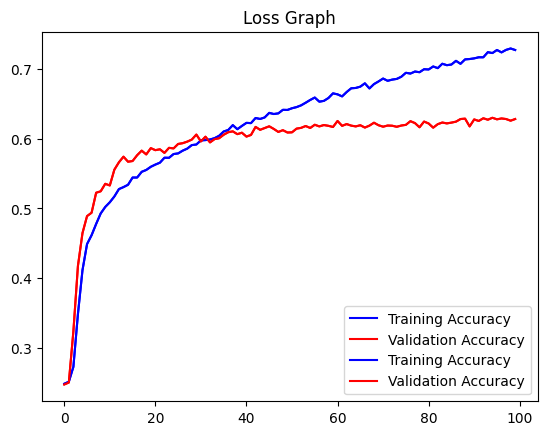

In [21]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
epochs=range(len(acc))
plt.plot(epochs,acc,'b',label='Training Accuracy')
plt.plot(epochs,val_acc,'r',label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
loss=history.history['loss']
val_loss=history.history['val_loss']
epoch=range(len(acc))

plt.plot(epochs,acc,'b',label='Training Accuracy')
plt.plot(epochs,val_acc,'r',label='Validation Accuracy')
plt.title('Loss Graph')
plt.legend()


plt.show()

#Test With Image Data

Original output: surprise
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 858ms/step
Predicted Output: surprise


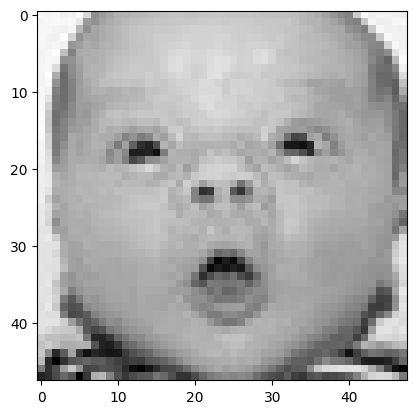

In [22]:

import random
image_index=random.randint(0,len(test))
print('Original output:',test['label'][image_index])
pred=model.predict(x_test[image_index].reshape(1,48,48,1))
prediction_label=le.inverse_transform([pred.argmax()])[0]
print('Predicted Output:',prediction_label)
plt.imshow(x_test[image_index].reshape(48,48),cmap='gray')

Original output: sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicted Output: sad


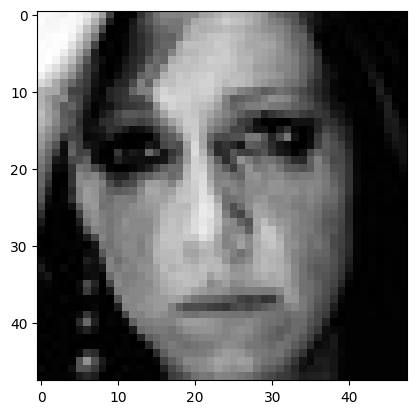

In [25]:

import random
image_index=random.randint(0,len(test))
print('Original output:',test['label'][image_index])
pred=model.predict(x_test[image_index].reshape(1,48,48,1))
prediction_label=le.inverse_transform([pred.argmax()])[0]
print('Predicted Output:',prediction_label)
plt.imshow(x_test[image_index].reshape(48,48),cmap='gray')

#Custom Image Testing

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Output: happy


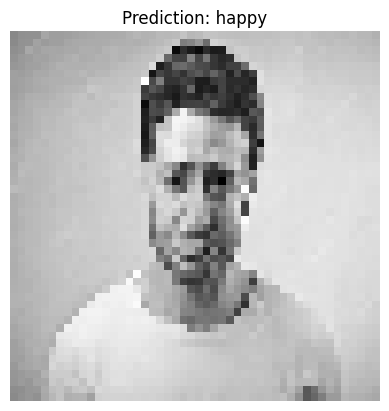

In [28]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def predict_custom_image(img_path, model, label_encoder):
    """
    Loads an external image, preprocesses it, and predicts with the trained model.
    """
    # Load image in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Error: Image not found or path is incorrect.")
        return

    # Resize to model input size (48x48)
    img_resized = cv2.resize(img, (48, 48))

    # Normalize (if your model trained with normalized images)
    img_resized = img_resized / 255.0

    # Reshape for model input (1, 48, 48, 1)
    img_input = img_resized.reshape(1, 48, 48, 1)

    # Prediction
    pred = model.predict(img_input)
    prediction_label = label_encoder.inverse_transform([pred.argmax()])[0]

    # Show results
    print("Predicted Output:", prediction_label)

    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Prediction: {prediction_label}")
    plt.axis('off')
    plt.show()

# Example usage:
predict_custom_image("image.png", model, le)
